In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import chi2, multivariate_normal
from tqdm.notebook import tqdm
sns.set()
#sns.set_style('dark')
sns.set_palette("viridis")

In [2]:
from numba import jit

@jit(nopython=True)
def amoc_gen(alarms, first_detect_time, last_detect_time, max_time_detection):
    """
    Generate an AMOC curve.
    Arguments: 
        alarms: p-vals?
        first_detect_time
        max_time_detection: the maximum number of days to detect a fire (int)
    Returns: 
        FPR_array: false positive rates (list)
        detection_array: days to detection time (list)
    """
    thresholds = np.arange(0, 1, .001)
    FPR_array = []
    detection_array = []

    # Check FPR and days to detection for each probability threshold
    for threshold in thresholds:
        detected = False
        detection_time = 0
        false_positives = 0
        true_negatives = 0
        
        for p_value in alarms:
            
            # Two cases: false postive and true positive
            if p_value <= threshold:
                if detection_time < first_detect_time or detection_time > last_detect_time: # Check for false positive
                    false_positives += 1
                
                else: # True positive: fire detected
                    detected = True
                    detection_array.append(detection_time - first_detect_time)
                    break
            
            else: # Two cases: false negative and true negative
                if detection_time < first_detect_time: # Check for true negative -- needed for FPR
                    true_negatives += 1
            detection_time += 1

        if false_positives + true_negatives != 0:
            fp_rate = (false_positives) / (false_positives + true_negatives)
            
        else:
            fp_rate = 0
            pass

        FPR_array.append(fp_rate)
        if not detected:
            detection_array.append(max_time_detection)
    
    return FPR_array, detection_array

def apply_fdr_correction(p_vals_all, alpha=0.05):
    corrected_p_vals_all = []
    for i in range(p_vals_all.shape[0]):
        rejected, corrected_p_vals_i = fdrcorrection(p_vals_all[i], alpha=alpha)
        corrected_p_vals_all.append(corrected_p_vals_i)
    return np.array(corrected_p_vals_all)

In [3]:
@jit(nopython=True)
def average_AMOC(AMOC_points):
    """
    Generate an average AMOC curve.
    Arguments: 
        alarms_dataset: List of lists of tuples, where points are FPRs and associated
                        detection times
                        [ [(FPR, detection time), (FPR, detection time)], ...] 
                          [(FPR, detection time), (FPR, detection time)], ...] 
                          ...
                        ]
    Returns: 
        mean_days_per_threshold: list of mean days to detection for each threshold
    """
    mean_days_per_threshold = []
    thresholds = np.arange(0, 1, .0001)
    
    # Find mean detection time for each threshold
    for k in range(len(thresholds)):
        threshold = thresholds[k]
        summed_days = 0
        
        # Approximate detection time for threshold using closest FPR in each simulation
        for i in range(0, len(AMOC_points)):
            current_dataset = AMOC_points[i]  # Get list of alarm values
            closest_pair = current_dataset[0] # Find pair with closest probability threshold
            
            for j in range(0, len(current_dataset)):
                curr_point = current_dataset[j]     # point: (FPR, days to detection)
                if np.abs(curr_point[0] - threshold) < np.abs(closest_pair[0] - threshold):
                    closest_pair = curr_point
            
            # sum the detection times of each dataset that correspond with 
            # probability threshold
            summed_days += closest_pair[1]
        
        mean_days = summed_days / len(AMOC_points)
        mean_days_per_threshold.append(mean_days)
    
    return mean_days_per_threshold, thresholds

In [4]:
sim_results_path = '/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/simulation_results/'
sim_results_path_cai = '/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/simulation_results_cai/'

In [5]:
# mult_coeff is only for dim=50
simulation_prefixes = ['cai_model_one', 'cai_model_three', 
                       'orthogonal', 'cholesky']
#simulation_prefixes = ['cai_model_one']
# no change only goes up to dim=30
no_change_prefixes = ['cai_model_one_no_change', 'cai_model_three_no_change', 
                       'orthogonal_no_change', 'cholesky_no_change']
# handle dim=50 separately?
simulation_dims = ['_20', '_30', '_50', '_100']
#simulation_dims = ['_100']
# random seeds
random_seeds = np.arange(50, 75)
random_seeds_dim_100 = np.arange(50, 60)
# first possible detection time
first_possible_detect_time = 401
last_possible_detect_time = 600

In [6]:
def amoc_lrt_vals(lrt_vals, first_possible_detect_time, last_possible_detect_time):
    # input should be padded vals
    p_vals = np.array([chi2.pdf(lrt_vals[:, i], 2) for i in range(lrt_vals.shape[1])]).T
    p_vals_corrected = apply_fdr_correction(p_vals)
    fprs = []
    detections = []
    for i in range(p_vals_corrected.shape[1]):
        fpr_array, detection_array = amoc_gen(p_vals_corrected[:, i], 
                                              first_detect_time=first_possible_detect_time, 
                                              last_detect_time=last_possible_detect_time, 
                                              max_time_detection=last_possible_detect_time-first_possible_detect_time)
        fprs.append(fpr_array)
        detections.append(detection_array)
    fprs = np.array(fprs)
    detections = np.array(detections)
    fpr_result = fprs.max(axis=0)
    detect_result = detections.min(axis=0)
    
    return fpr_result, detect_result
    
def symmetrize_from_vector(a, dim):
    """
    Turns a vector of lower triangular matrix entries into symmetric matrix
    """
    A = np.zeros((dim,dim))
    A[np.tril_indices(A.shape[0], k = 0)] = a
    A = A + A.T - np.diag(np.diag(A))

    return A

def get_h_matrices(full_path, num_mats, dim):
    H_s = []
    for i in range(num_mats):
        H_i = np.loadtxt(os.path.join(full_path, 'matrix_{}.csv'.format(i)))
        H_s.append(symmetrize_from_vector(H_i, dim))
    return np.array(H_s)

In [7]:
"""
This box is for loading my algorithm's results
"""

all_sims_names = []
all_fprs = []
all_detects = []
all_amoc_means = []
all_amoc_thresholds = []
for sim in simulation_prefixes:
    for dim in simulation_dims:
        if dim == '_100':
            curr_r_seeds = random_seeds_dim_100
        else:
            curr_r_seeds = random_seeds
        print(sim, dim)
        curr_fprs = []
        curr_detects = []
        fpr_detect_pairs = []
        for seed in curr_r_seeds:
            full_path = os.path.join(sim_results_path, sim+dim+"/"+str(seed))
            lrt_vals = np.loadtxt(os.path.join(full_path, 'lrt_vals.csv'), delimiter=',')
            lrt_vals_padded = np.pad(lrt_vals, [(100, 100), (0,0)], mode='constant')
            changed_indices = np.loadtxt(os.path.join(full_path, 'changed_indx.csv')).astype(int)
            H_s = get_h_matrices(full_path, num_mats=lrt_vals_padded.shape[1], dim=int(dim[1:]))
            if dim == '_100':
                fpr_result, detect_result = amoc_lrt_vals(lrt_vals_padded, 
                                                          101,
                                                          300)
            else:
                fpr_result, detect_result = amoc_lrt_vals(lrt_vals_padded, 
                                                          first_possible_detect_time,
                                                          last_possible_detect_time)
            curr_fprs.append(fpr_result)
            curr_detects.append(detect_result)
            merged_list = [(fpr_result[i], detect_result[i]) for i in range(0, len(fpr_result))]
            fpr_detect_pairs.append(merged_list)
        all_fprs.append(curr_fprs)
        all_detects.append(curr_detects)
        means_per_threshold, thresholds = average_AMOC(np.array(fpr_detect_pairs))
        all_amoc_means.append(list(means_per_threshold))
        all_amoc_thresholds.append(thresholds)
        all_sims_names.append(sim+dim)
#         plt.plot(thresholds, means_per_threshold, '.b-')
#         plt.xlabel('Threshold')
#         plt.ylabel('Detection Time')
#         plt.title('Average AMOC Curve for {} at dim {}'.format(sim, dim))
all_amoc_means = np.array(all_amoc_means)
all_amoc_thresholds = np.array(all_amoc_thresholds)
#all_fprs = np.array(all_fprs)
#all_detects = np.array(all_detects)

cai_model_one _20
cai_model_one _30
cai_model_one _50
cai_model_one _100
cai_model_three _20
cai_model_three _30
cai_model_three _50
cai_model_three _100
orthogonal _20
orthogonal _30
orthogonal _50
orthogonal _100
cholesky _20
cholesky _30
cholesky _50
cholesky _100


In [ ]:
anderson_decomp_means = all_amoc_means
anderson_decomp_fdr = all_amoc_thresholds

In [ ]:
print(anderson_decomp_means)

In [ ]:
fig, ax = plt.subplots(4, 7, figsize = (20, 11), sharex=True, sharey=True)

counter = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].plot(anderson_decomp_fdr[counter], anderson_decomp_means[counter])
        ax[i,j].set_title(all_sims_names[counter])
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='FPR', ylabel='Detection Time')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
fig.suptitle('Average AMOC Curves per Simulation', 
             fontsize='x-large', fontweight='semibold');

In [8]:
@jit(nopython=True)
def indicator_global_stat(p, alpha=0.01):
    q_alpha = -np.log(8*np.pi)-2*np.log(np.log(np.power(1-alpha, -1)))
    threshold = q_alpha+4*np.log(p)-np.log(np.log(p))

    return threshold

@jit(nopython=True)
def amoc_gen_cai(alarms, first_detect_time, last_detect_time, max_time_detection, p):
    """
    Generate an AMOC curve.
    Arguments: 
        alarms: p-vals?
        first_detect_time
        max_time_detection: the maximum number of days to detect a fire (int)
    Returns: 
        FPR_array: false positive rates (list)
        detection_array: days to detection time (list)
    """
    thresholds = np.arange(0, 1, .001)
    FPR_array = []
    detection_array = []

    # Check FPR and days to detection for each probability threshold
    for threshold in thresholds:
        thr = indicator_global_stat(p, alpha=threshold)
        detected = False
        detection_time = 0
        false_positives = 0
        true_negatives = 0
        
        for p_value in alarms:
            
            # Two cases: false postive and true positive
            if p_value >= thr:
                if detection_time < first_detect_time or detection_time > last_detect_time: # Check for false positive
                    false_positives += 1
                
                else: # True positive: fire detected
                    detected = True
                    detection_array.append(detection_time - first_detect_time)
                    break
            
            else: # Two cases: false negative and true negative
                if detection_time < first_detect_time: # Check for true negative -- needed for FPR
                    true_negatives += 1
            detection_time += 1

        if false_positives + true_negatives != 0:
            fp_rate = (false_positives) / (false_positives + true_negatives)
            
        else:
            fp_rate = 0
            pass

        FPR_array.append(fp_rate)
        if not detected:
            detection_array.append(max_time_detection)
    
    return FPR_array, detection_array

def amoc_lrt_vals_cai(lrt_vals, dim, first_possible_detect_time, last_possible_detect_time):
    # input should be padded vals
    #p_vals = np.array([chi2.pdf(lrt_vals[:, i], 2) for i in range(lrt_vals.shape[1])]).T
    fprs = []
    detections = []
    
    fprs, detections = amoc_gen_cai(lrt_vals, 
                                    first_detect_time=first_possible_detect_time, 
                                    last_detect_time=last_possible_detect_time, 
                                    max_time_detection=last_possible_detect_time-first_possible_detect_time,
                                    p=dim)

    fprs = np.array(fprs)
    detections = np.array(detections)
    
    return fprs, detections

In [15]:
"""
This box is for loading Cai Algorithm results
"""

all_sims_names = []
all_fprs_cai = []
all_detects_cai = []
all_amoc_means = []
all_amoc_thresholds = []
for sim in simulation_prefixes:
    for dim in simulation_dims:
        if dim == '_100':
            curr_r_seeds = random_seeds_dim_100
        else:
            curr_r_seeds = random_seeds
        print(sim, dim)
        curr_fprs = []
        curr_detects = []
        fpr_detect_pairs = []
        for seed in curr_r_seeds:
            full_path = os.path.join(sim_results_path_cai, sim+dim+"/"+str(seed))
            lrt_vals = np.loadtxt(os.path.join(full_path, 'global_test_vals.csv'), delimiter=',')
            lrt_vals_padded = np.pad(lrt_vals, 100, mode='constant')
            changed_indices = np.loadtxt(os.path.join(full_path, 'changed_indx.csv')).astype(int)
            #H_s = get_h_matrices(full_path, num_mats=lrt_vals_padded.shape[1], dim=int(dim[1:]))
            if dim == '_100':
                fpr_result, detect_result = amoc_lrt_vals_cai(lrt_vals_padded, 
                                                              first_possible_detect_time=102,
                                                              last_possible_detect_time=301,
                                                              dim=int(dim[1:]))
            else:
                fpr_result, detect_result = amoc_lrt_vals_cai(lrt_vals_padded, 
                                                              first_possible_detect_time=first_possible_detect_time,
                                                              last_possible_detect_time=last_possible_detect_time,
                                                              dim=int(dim[1:]))
            curr_fprs.append(fpr_result)
            curr_detects.append(detect_result)
            merged_list = [(fpr_result[i], detect_result[i]) for i in range(0, len(fpr_result))]
            fpr_detect_pairs.append(merged_list)
        all_fprs_cai.append(curr_fprs)
        all_detects_cai.append(curr_detects)
        means_per_threshold, thresholds = average_AMOC(np.array(fpr_detect_pairs))
        all_amoc_means.append(list(means_per_threshold))
        all_amoc_thresholds.append(thresholds)
        all_sims_names.append(sim+dim)
#         plt.plot(thresholds, means_per_threshold, '.b-')
#         plt.xlabel('Threshold')
#         plt.ylabel('Detection Time')
#         plt.title('Average AMOC Curve for {} at dim {}'.format(sim, dim))
all_amoc_means = np.array(all_amoc_means)
all_amoc_thresholds = np.array(all_amoc_thresholds)

cai_model_one _20
cai_model_one _30
cai_model_one _50
cai_model_one _100
cai_model_three _20
cai_model_three _30
cai_model_three _50
cai_model_three _100
orthogonal _20
orthogonal _30
orthogonal _50
orthogonal _100
cholesky _20
cholesky _30
cholesky _50
cholesky _100


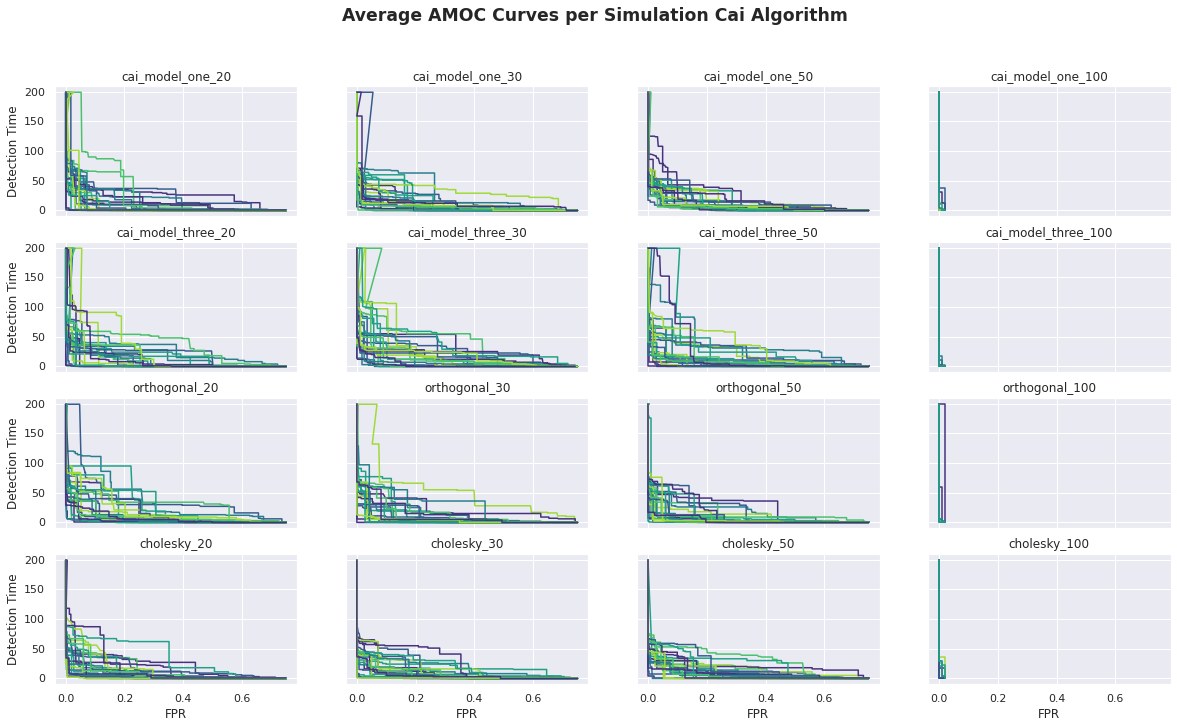

In [18]:
fig, ax = plt.subplots(4, 4, figsize = (20, 11), sharex=True, sharey=True)

counter = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        curr_fdrs = all_fprs_cai[counter]
        curr_detects = all_detects_cai[counter]
        for k in range(len(curr_fdrs)):
            ax[i,j].plot(curr_fdrs[k], curr_detects[k])
            ax[i,j].set_title(all_sims_names[counter])
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='FPR', ylabel='Detection Time')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
fig.suptitle('Average AMOC Curves per Simulation Cai Algorithm', 
             fontsize='x-large', fontweight='semibold');

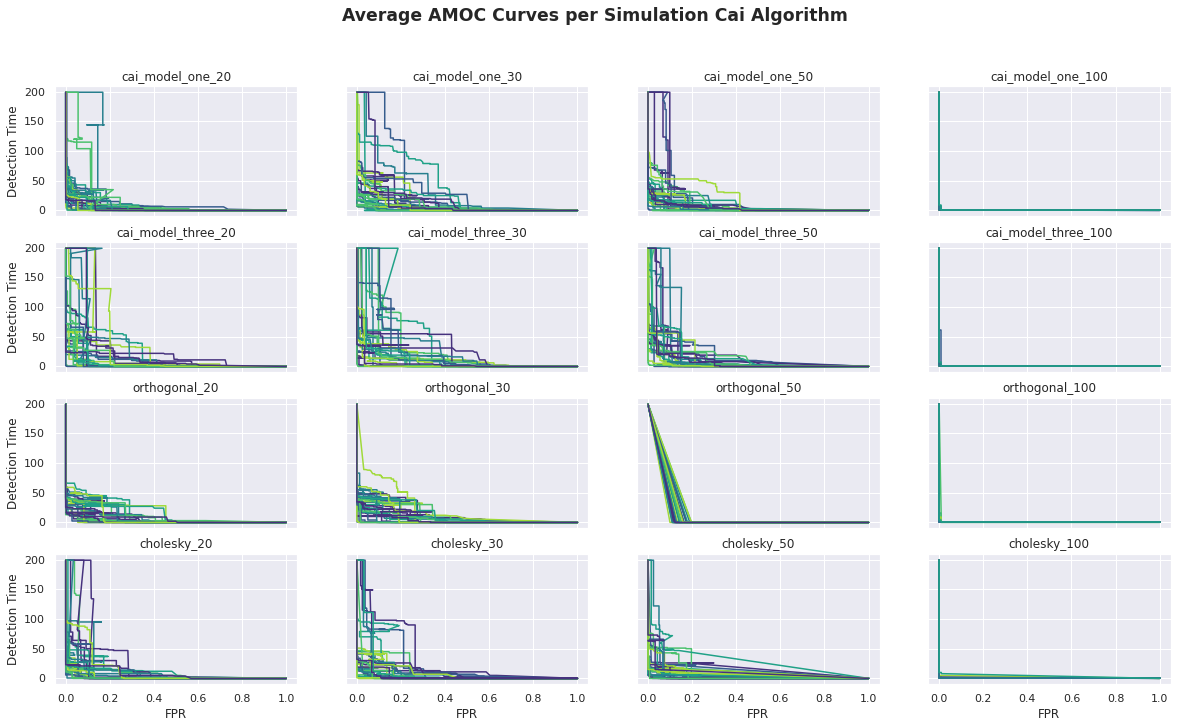

In [19]:
fig, ax = plt.subplots(4, 4, figsize = (20, 11), sharex=True, sharey=True)

counter = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        curr_fdrs = all_fprs[counter]
        curr_detects = all_detects[counter]
        for k in range(len(curr_fdrs)):
            ax[i,j].plot(curr_fdrs[k], curr_detects[k])
            ax[i,j].set_title(all_sims_names[counter])
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='FPR', ylabel='Detection Time')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
fig.suptitle('Average AMOC Curves per Simulation Cai Algorithm', 
             fontsize='x-large', fontweight='semibold');

In [ ]:
plt.plot(all_fprs_cai[0][1], all_detects_cai[0][1])

In [ ]:
cai_means = all_amoc_means
cai_fdr = all_amoc_thresholds

In [ ]:
fig, ax = plt.subplots(4, 6, figsize = (20, 11), sharex=True, sharey=True)

counter = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].plot(cai_fdr[counter], cai_means[counter])
        ax[i,j].set_title(all_sims_names[counter])
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='FPR', ylabel='Detection Time')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
fig.suptitle('Average AMOC Curves per Simulation Cai Algorithm- Averaged Over 25 Seeds', 
             fontsize='x-large', fontweight='semibold');

In [ ]:
fig, ax = plt.subplots(4, 6, figsize = (30, 19), sharex=True, sharey=True)

counter = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].plot(anderson_decomp_fdr[counter], anderson_decomp_means[counter], 'b', label='Ours')
        ax[i,j].plot(cai_fdr[counter], cai_means[counter], 'r', label='Cai et al.')
        ax[i,j].set_title(all_sims_names[counter], fontsize=15)
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='FPR', ylabel='Detection Time')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
handles, labels = ax[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', prop={'size': 22})
plt.savefig('../results/amoc_curve_comparison.png')

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

In [ ]:
def get_p_vals(lrt_vals):
    p_vals = np.array([chi2.pdf(lrt_vals[i], 2) for i in range(len(lrt_vals))]).T
    _, p_vals_corrected = fdrcorrection(p_vals)
    return np.array(p_vals_corrected)

In [ ]:
sim_results_path_precision = '/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/simulation_results_precision//'
sim_results_path_precision_cai = '/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/simulation_results_precision_cai/'

In [ ]:
"""
ROC Processing - Our alg
"""


simulation_prefixes = ['cai_model_one', 'cai_model_three', 
                        'orthogonal', 'cholesky']
no_change_prefixes = ['cai_model_one_no_change', 'cai_model_three_no_change',
                    'orthogonal_no_change', 'cholesky_no_change']
simulation_dims = ['_6', '_10', '_15', '_20', '_30', '_50']
seeds = np.arange(50, 100)

fprs_sims = []
tprs_sims = []
precs_sims = []
recalls_sims = []
for i in range(len(simulation_prefixes)):
    sim_change = simulation_prefixes[i]
    sim_no_change = no_change_prefixes[i]
    print(sim_change)
    print(sim_no_change)
    fprs_dim = []
    tprs_dim = []
    precs_dim = []
    recalls_dim = []
    for dim in simulation_dims:
        labels = []
        min_p_vals = []
        for seed in seeds:
            full_path_change = os.path.join(sim_results_path_precision, sim_change+dim+"/"+str(seed))
            full_path_no_change = os.path.join(sim_results_path_precision, sim_no_change+dim+"/"+str(seed))
            # lrt_vals is shape: (num_matrices, )
            lrt_vals_change = np.loadtxt(os.path.join(full_path_change, 'lrt_vals.csv'), delimiter=',')
            p_vals_change = get_p_vals(lrt_vals_change)
            lrt_vals_no_change = np.loadtxt(os.path.join(full_path_no_change, 'lrt_vals.csv'), delimiter=',')
            p_vals_no_change = get_p_vals(lrt_vals_no_change)
            min_p_vals.append(p_vals_change.min())
            labels.append(0)
            min_p_vals.append(p_vals_no_change.min())
            labels.append(1)
        labels = np.array(labels)
        min_p_vals = np.array(min_p_vals)
        labels = 1 - labels
        min_p_vals = 1 - min_p_vals
        fpr, tpr, _ = roc_curve(labels,  min_p_vals)
        prec, recall, _ = precision_recall_curve(labels, min_p_vals)
        fprs_dim.append(fpr)
        tprs_dim.append(tpr)
        precs_dim.append(prec)
        recalls_dim.append(recall)
    fprs_sims.append(fprs_dim)
    tprs_sims.append(tprs_dim)
    precs_sims.append(precs_dim)
    recalls_sims.append(recalls_dim)

In [ ]:
"""
ROC Processing - Cai Alg
"""

fprs_sims_cai = []
tprs_sims_cai = []
precs_sims_cai = []
recalls_sims_cai = []
for i in range(len(simulation_prefixes)):
    sim_change = simulation_prefixes[i]
    sim_no_change = no_change_prefixes[i]
    print(sim_change)
    print(sim_no_change)
    fprs_dim = []
    tprs_dim = []
    precs_dim = []
    recalls_dim = []
    for dim in simulation_dims:
        labels = []
        min_p_vals = []
        for seed in seeds:
            full_path_change = os.path.join(sim_results_path_precision_cai, sim_change+dim+"/"+str(seed))
            full_path_no_change = os.path.join(sim_results_path_precision_cai, sim_no_change+dim+"/"+str(seed))
            # lrt_vals is shape: (num_matrices, )
            lrt_vals_change = np.loadtxt(os.path.join(full_path_change, 'global_test_vals.csv'), delimiter=',')
            #p_vals_change = get_p_vals(lrt_vals_change)
            lrt_vals_no_change = np.loadtxt(os.path.join(full_path_no_change, 'global_test_vals.csv'), 
                                            delimiter=',')
            #p_vals_no_change = get_p_vals(lrt_vals_no_change)
            min_p_vals.append(lrt_vals_change)
            #min_p_vals.append(p_vals_change.min())
            labels.append(1) # for cai, label should be positive
            #min_p_vals.append(p_vals_no_change.min())
            min_p_vals.append(lrt_vals_no_change)
            labels.append(0) # for cai, label should be negative
        labels = np.array(labels)
        #min_p_vals = np.array(min_p_vals)
        fpr, tpr, _ = roc_curve(labels,  min_p_vals)
        prec, recall, _ = precision_recall_curve(labels, min_p_vals)
        fprs_dim.append(fpr)
        tprs_dim.append(tpr)
        precs_dim.append(prec)
        recalls_dim.append(recall)
    fprs_sims_cai.append(fprs_dim)
    tprs_sims_cai.append(tprs_dim)
    precs_sims_cai.append(precs_dim)
    recalls_sims_cai.append(recalls_dim)

In [ ]:
counter = 0
sim_names = []
for i in range(len(simulation_prefixes)):
    for dim in simulation_dims:
        sim_names.append(simulation_prefixes[i]+dim)
sim_names

In [ ]:
fig, ax = plt.subplots(4, 6, figsize = (30, 19), sharex=True, sharey=True)

counter = 0
for i in range(len(simulation_prefixes)):
    for j in range(len(simulation_dims)):
        ax[i,j].plot(fprs_sims[i][j], tprs_sims[i][j], 'b', label='Ours')
        ax[i,j].plot(fprs_sims_cai[i][j], tprs_sims_cai[i][j], 'r', label='Cai et al.')
        ax[i,j].set_title(sim_names[counter], fontsize=15)
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='FPR', ylabel='TPR')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
handles, labels = ax[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', prop={'size': 22})
plt.savefig('../results/roc_curve.png')

In [ ]:
fig, ax = plt.subplots(4, 6, figsize = (30, 19), sharex=True, sharey=True)

counter = 0
for i in range(len(simulation_prefixes)):
    for j in range(len(simulation_dims)):
        ax[i,j].plot(recalls_sims[i][j], precs_sims[i][j], 'b', label='Ours')
        ax[i,j].plot(recalls_sims_cai[i][j], precs_sims_cai[i][j], 'r', label='Cai et al.')
        ax[i,j].set_title(sim_names[counter], fontsize=15)
        counter += 1
        
for ax_ in ax.flat:
    ax_.set(xlabel='Recall', ylabel='Precision')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax_ in ax.flat:
    ax_.label_outer()
handles, labels = ax[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', prop={'size': 22})
plt.savefig('../results/prec_rec_curve.png')